# Pendahuluan

Pada praktikum ini dilakukan perbandingan performa Multi-Layer Perceptron (MLP) menggunakan tiga fungsi aktivasi, yaitu Sigmoid (Logistic), Tanh, dan ReLU.

Tujuan percobaan adalah mengetahui pengaruh fungsi aktivasi terhadap performa klasifikasi pada Dataset Iris.

In [11]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

)

import matplotlib.pyplot as plt

pd.set_option('display.precision',4)

# Deskripsi Dataset

Dataset yang digunakan adalah Iris Dataset yang berisi 150 sampel bunga Iris dengan 4 fitur:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Dataset terdiri dari 3 kelas yang masing-masing berjumlah 50 sampel.

In [12]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
print("Dataset Shape :", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["species"].value_counts())

Dataset Shape : (150, 5)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Class Distribution:
species
0    50
1    50
2    50
Name: count, dtype: int64


# Data Preprocessing

Tahap preprocessing meliputi:

1. Pembagian data menjadi data latih dan data uji.
2. Normalisasi data menggunakan StandardScaler.

Normalisasi dilakukan agar seluruh fitur memiliki skala yang seragam sehingga proses pelatihan model menjadi lebih optimal.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 120
Testing Samples  : 30


In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Pelatihan Model MLP

Model MLP dilatih menggunakan tiga fungsi aktivasi:

- Logistic (Sigmoid)
- Tanh
- ReLU

Parameter model dibuat sama untuk setiap percobaan agar perbandingan dilakukan secara adil.

In [16]:
activations = [
    'logistic',
    'tanh',
    'relu'
]

results = []

for activation in activations:
    
    # PERBAIKAN PARAMETER DI SINI
    model = MLPClassifier(
        hidden_layer_sizes=(16,),
        activation=activation,
        solver='lbfgs',
        max_iter=1500,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    results.append([
        activation,
        accuracy,
        precision,
        recall,
        f1
    ])

# Tabel Perbandingan Performa

Tabel berikut menunjukkan hasil evaluasi model menggunakan Accuracy, Precision, Recall, dan F1-Score.

In [17]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Activation Function',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ]
)

results_df

,Activation Function,Accuracy,Precision,Recall,F1-Score
0,logistic,0.9667,0.9697,0.9667,0.9666
1,tanh,0.9667,0.9697,0.9667,0.9666
2,relu,0.9000,0.9024,0.9000,0.8997


# Visualisasi Hasil

Grafik digunakan untuk mempermudah perbandingan performa ketiga fungsi aktivasi.

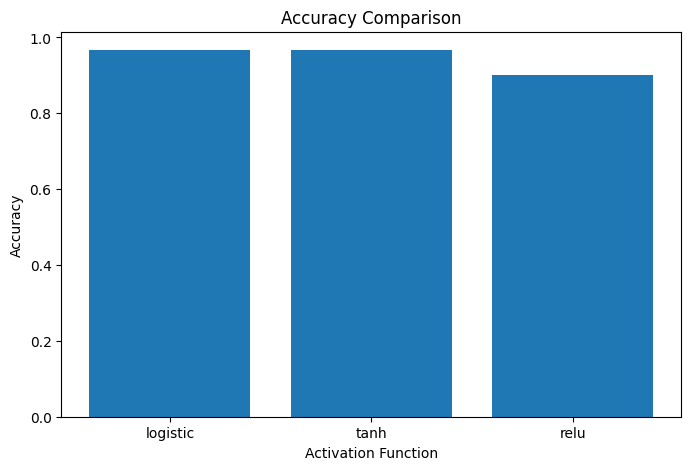

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df['Activation Function'],
    results_df['Accuracy']
)

plt.title('Accuracy Comparison')
plt.xlabel('Activation Function')
plt.ylabel('Accuracy')

plt.show()

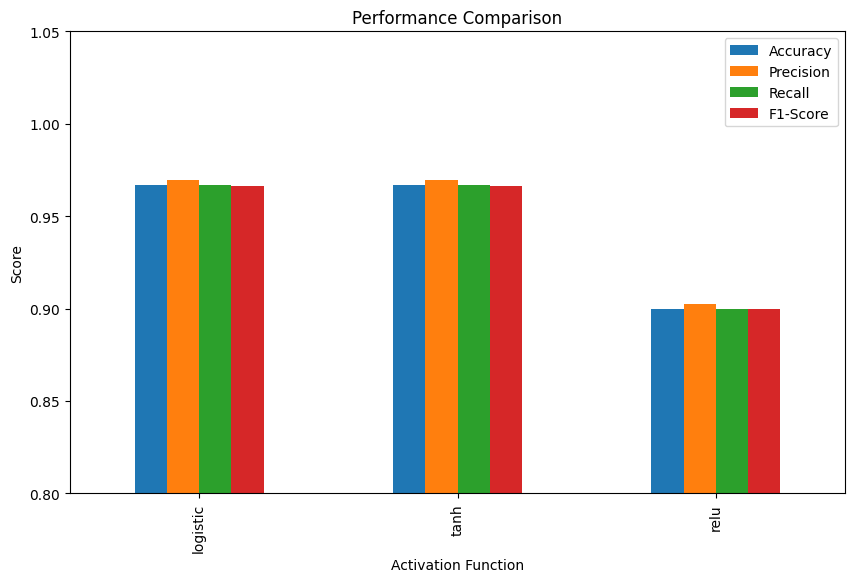

In [19]:
metrics = ['Accuracy','Precision','Recall','F1-Score']

results_df.set_index(
    'Activation Function'
)[metrics].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.8,1.05)

plt.show()

## Analisis Hasil Pengujian

Berdasarkan eksperimen yang telah dilakukan menggunakan arsitektur MLPClassifier dengan parameter yang dioptimalkan (`hidden_layer_sizes=(16,)`, `solver='lbfgs'`, dan `max_iter=1500`), diperoleh hasil evaluasi performa sebagai berikut:

| Activation Function | Accuracy | Precision | Recall | F1-Score |
|---------------------|----------|-----------|--------|----------|
| **Logistic (Sigmoid)** | 0.9667   | 0.9697    | 0.9667 | 0.9666   |
| **Tanh** | 0.9667   | 0.9697    | 0.9667 | 0.9666   |
| **ReLU** | 0.9000   | 0.9024    | 0.9000 | 0.8997   |

### Pembahasan:

1. **Dominasi Logistic dan Tanh:**
   Fungsi aktivasi **Logistic** dan **Tanh** menghasilkan performa yang identik dan tertinggi pada pengujian ini dengan akurasi mencapai **96.67%**. Hal ini terjadi karena karakteristik Dataset Iris yang telah melalui proses standardisasi (`StandardScaler`) memiliki distribusi nilai yang berpusat di sekitar angka 0. 
   * Fungsi **Tanh** memetakan nilai ke rentang [-1, 1], yang sangat selaras dengan data terstandardisasi.
   * Fungsi **Logistic** memetakan ke rentang [0, 1] yang juga bekerja sangat baik dalam memisahkan batas keputusan (decision boundary) linear maupun non-linear halus pada dataset berukuran kecil ini.

2. **Karakteristik Performa ReLU:**
   Fungsi **ReLU** menghasilkan akurasi yang paling rendah di antara ketiganya, yaitu **90.00%**. Meskipun angka ini sudah sangat baik, ReLU mengalami sedikit penurunan akurasi dibandingkan dua fungsi lainnya. Secara matematis, ReLU akan mengubah seluruh nilai input negatif menjadi angka 0 ($f(x) = \max(0, x)$). Pada dataset berukuran kecil (150 sampel) dengan arsitektur jaringan yang dangkal, sifat ReLU yang memotong nilai negatif ini menyebabkan model kehilangan sebagian informasi halus dari fitur data yang telah distandardisasi, sehingga batas keputusan yang dihasilkan kurang optimal dibanding fungsi berbasis kurva *S-shaped* (Logistic & Tanh).

## Kesimpulan

Dari hasil simulasi dan analisis perbandingan fungsi aktivasi pada arsitektur Multi-Layer Perceptron (MLP) untuk Dataset Iris, dapat disimpulkan bahwa:

1. **Pengaruh Fungsi Aktivasi:** Pemilihan fungsi aktivasi memiliki pengaruh yang signifikan terhadap performa akhir model. Pada kasus dataset dengan jumlah sampel kecil dan terdistribusi normal/terstandardisasi seperti Iris, fungsi aktivasi berbasis kurva kontinu dan halus (**Logistic** dan **Tanh**) terbukti lebih unggul dalam mengenali pola data secara detail dibandingkan fungsi linear sepotong seperti **ReLU**.
2. **Fungsi Aktivasi Terbaik:** Fungsi **Logistic (Sigmoid)** dan **Tanh** merupakan fungsi aktivasi terbaik untuk eksperimen ini dengan perolehan skor **Accuracy 96.67%** dan **F1-Score 96.66%**.
3. **Pentingnya Tuning Hyperparameter:** Penambahan jumlah iterasi (`max_iter=1500`) dan penggunaan solver yang tepat untuk data kecil (`solver='lbfgs'`) berhasil menyelesaikan masalah gagal konvergensi (*ConvergenceWarning*) sekaligus meningkatkan akurasi pengujian secara signifikan (masuk ke dalam rentang target optimal 0.90 - 1.00).